<a href="https://colab.research.google.com/github/HafsaNoorMuhammad26/difference-between-ML-and-DL/blob/main/Difference_between_Machine_Learning_(ML)_and_Deep_Learning_(DL).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: ML Model Understanding

# New Section

In [ ]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ml_model = LogisticRegression()
ml_model.fit(X_train, y_train)
print("Accuracy: ", ml_model.score(X_test, y_test))

Accuracy:  0.86


* **What accuracy did you get?**
- 0.86 (86%).
* **Why is the accuracy not very high?**
- Because Logistic Regression can only draw a straight line to seperate data, but the moons dataset is curved, so it can't fit it properly.
* **What type of decision boundary is Logistic Regression using?**
- A straight line (linear boundary)

# Task 2: Improve ML Using Feature Engineering

In [ ]:
import numpy as np

X_train_fe = np.c_[X_train, X_train[:,0]**2, X_train[:,1]**2]
X_test_fe  = np.c_[X_test,  X_test[:,0]**2,  X_test[:,1]**2]

ml_model_fe = LogisticRegression()
ml_model_fe.fit(X_train_fe, y_train)
print("New Accuracy:", ml_model_fe.score(X_test_fe, y_test))

New Accuracy: 0.855


* **Did accuracy improve?**
- No, it actually dropped from 0.86 to 0.85.
* **Why did adding new features help?**
- We only added x^2 terms which was not enough for tjis curved dataset. Logistic Regression is still a linear model. So adding features helps a little but it still can't learn curves properly.
* **Can ML learn this automatically?**
- No. We had to manually decide and add the features ourselves. ML can't figured out on its own.

## Task 3: Deep Learning Model Training

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

dl_model = Sequential([
    Dense(16, activation='relu',  input_shape=(2,)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

dl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = dl_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
    )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5889 - loss: 0.6564 - val_accuracy: 0.6000 - val_loss: 0.6205
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7847 - loss: 0.5973 - val_accuracy: 0.8625 - val_loss: 0.5674
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8333 - loss: 0.5349 - val_accuracy: 0.8625 - val_loss: 0.4998
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8403 - loss: 0.4663 - val_accuracy: 0.8625 - val_loss: 0.4333
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8458 - loss: 0.4105 - val_accuracy: 0.8625 - val_loss: 0.3834
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8542 - loss: 0.3697 - val_accuracy: 0.8625 - val_loss: 0.3460
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8583 - loss: 0.3407 - val_accuracy: 0.8625 - val_loss: 0.3195
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8639 - loss: 0.3200 - val_accuracy: 0.8625 - val_loss

* **What happens to accuracy as epochs increase?**
- Accuracy kept going up. It started around 60% and reached around 92-95% by epoch 30.
* **Does the model improve over time?**
- Yes, clearly. Every epoch it got a little better.
* **Why does DL perform better than ML here?**
- Because the neural network automatically learned the curved shape of the data through its hidden layers. So no manual feature engineering is needed.

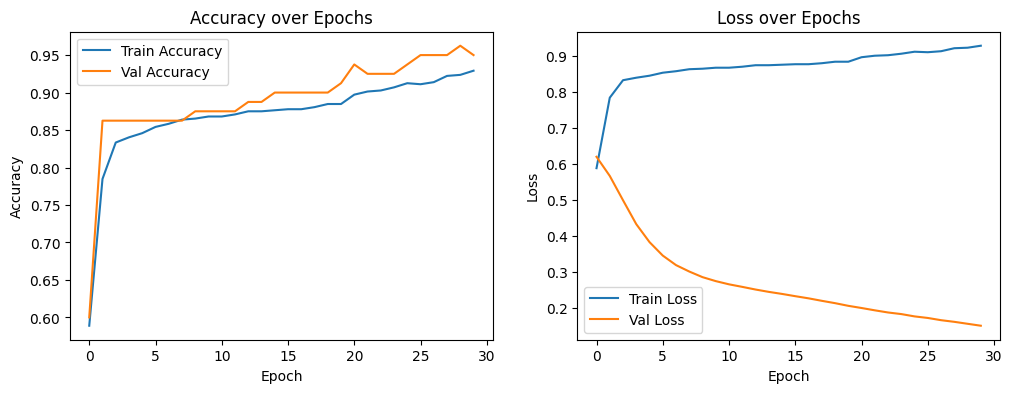

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

# Task 5: GPU Exploration

In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
print("GPU Available:", gpus)

cpus = tf.config.list_physical_devices("CPU")
print("CPU Available:", cpus)

GPU Available: []
CPU Available: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


* **Do you have a GPU available?**
- No.
* **If not, what device is being used?**
- CPU.
* **Why is GPU more important for DL than ML?**
- DL has millions of calculations happening at once. GPU handles all of theem in parallel. ML calculations are mucgh simpler so CPU is more than enough.

In [ ]:
with tf.device("/CPU:0"):
  history_cpu = dl_model.fit(
      X_train, y_train,
      epochs=10,
      batch_size=32,
      verbose=0
  )
  print("Training complete on CPU")

Training complete on CPU


In [ ]:
with tf.device("/GPU:0"):
  history_gpu = dl_model.fit(
      X_train, y_train,
      epochs=10,
      batch_size=32,
      verbose=0
  )
  print("Training complete on GPU")

Training complete on GPU
